In [1]:
import matplotlib.pyplot as plt
import os
import re
import shutil
import string

import pandas as pd

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras import losses

# Load Dataset

In [2]:
df = pd.read_csv('./ecommerceDataset.csv', header=None)
df.columns = ['label', 'text']
df.head()

,label,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


# EDA (Before Preprocessing)

## Missing value Check

In [3]:
df.isna().sum()

label    0
text     1
dtype: int64

## Target Distribution

<Axes: xlabel='label'>

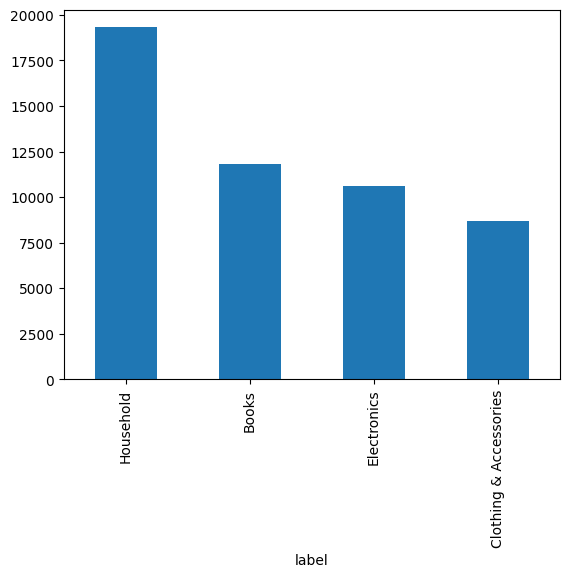

In [4]:
# Check the distribution of the labels
df['label'].value_counts().plot(kind='bar')

## Preprocessing

In [5]:
# Remove the rows with missing values
df = df.dropna()

## After Preprocessing EDA

## Word Cloud

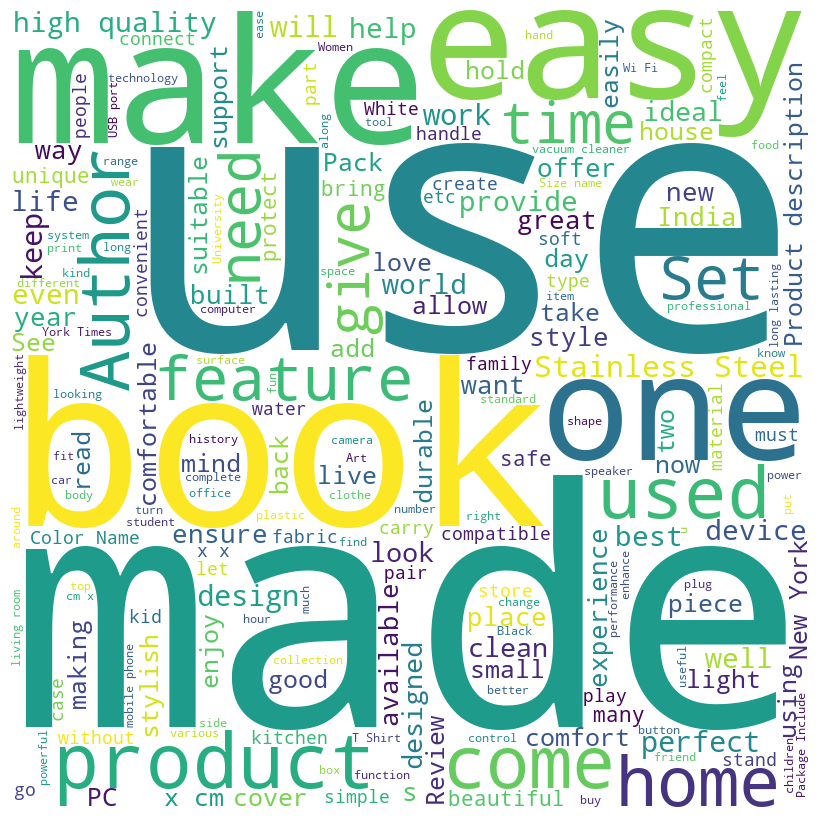

In [6]:
# Word cloud for the text
from wordcloud import WordCloud

wordcloud = WordCloud(width = 800, height = 800, background_color ='white', stopwords = None,).generate(' '.join(df['text']))

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

## 2nd Preprocessing

### Basic Cleaning

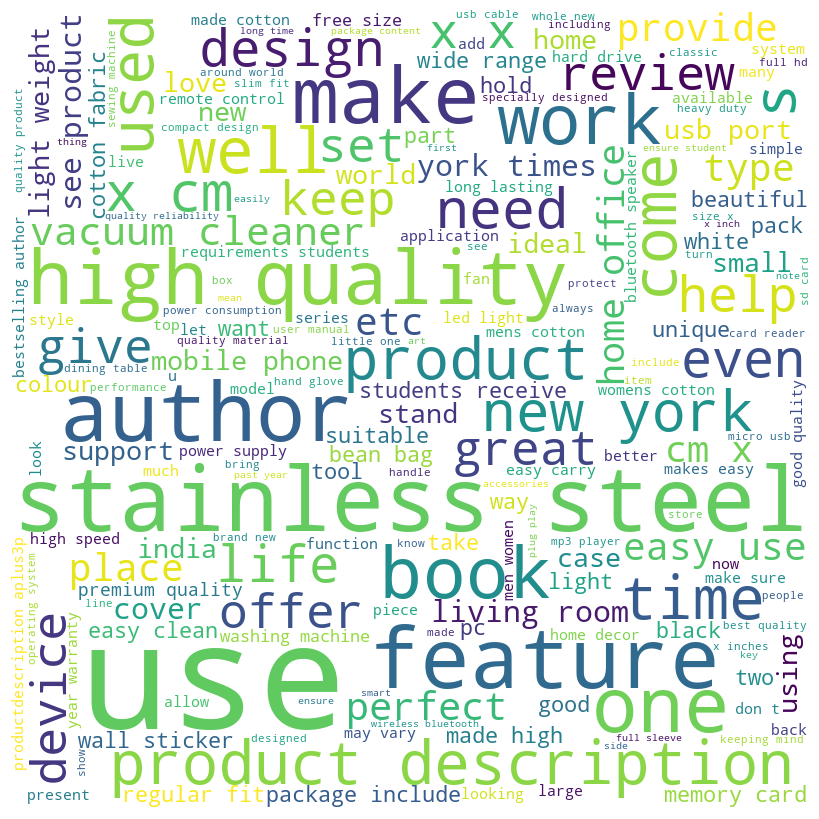

In [7]:
# Remove the stopwords
from nltk.corpus import stopwords

stop = set(stopwords.words('english'))
df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))

# Remove the punctuations
df['text'] = df['text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

# Convert the text to lowercase
df['text'] = df['text'].apply(lambda x: x.lower())

# Word cloud for the text
wordcloud = WordCloud(width = 800, height = 800, background_color ='white', stopwords = None,).generate(' '.join(df['text']))

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

### Remove single character

In [8]:
# Remove single characters
df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if len(word) > 1]))

# Remove 2 characters words
df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if len(word) > 2]))

### Remove Non-English Words

In [9]:
# Remove Non-English words with corpus
from nltk.corpus import words

english_words = set(words.words())
df['text'] = df['text'].apply(lambda x: ' '.join([word for word in x.split() if word in english_words]))



### Check for empyt strings and remove them

In [10]:
# check for empty strings and remove
df['text'] = df['text'].apply(lambda x: x if x != '' else None)
df = df.dropna()

# Cleaned Data

In [11]:
df.sample(5)

,label,text
49272,Electronics,quick charge wall charger adapter
39516,Clothing & Accessories,infant baby lovely ice cream tops cute tutu sk...
44705,Electronics,boat bass bass one button red boat polished me...
37786,Clothing & Accessories,morph pink maternity hygiene cotton fit throug...
34934,Clothing & Accessories,cotton lounge


<Axes: xlabel='label'>

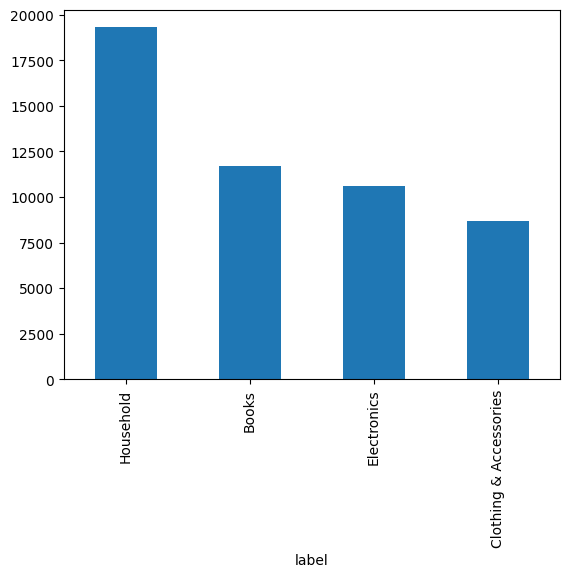

In [12]:
df['label'].value_counts().plot(kind='bar')

# Lemmatization

In [15]:
# Lemmaization
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['text'] = df['text'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))
df.sample(5)

,label,text
30407,Books,you can heal your life review seen hay series ...
15577,Household,room halogen heater heating element room heate...
18190,Household,paint zoom electric paint zoom ultimate elite ...
32602,Clothing & Accessories,vintage wide elastic stretch metal buckle wais...
217,Household,japan hair wax japan hair wax intact day witho...


# Tokenization

In [16]:
# Split the data into training and val and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [17]:
# Tokenize the text
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_val = tokenizer.texts_to_sequences(X_val)

# Pad the sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=100, padding='post', truncating='post')
X_val = pad_sequences(X_val, maxlen=100, padding='post', truncating='post')

# Convert the labels to one-hot encoding
from sklearn.preprocessing import LabelBinarizer

encoder = LabelBinarizer()
y_train = encoder.fit_transform(y_train)
y_val = encoder.transform(y_val)

## Transform to Tensor

In [37]:
# Transform to Tensor
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
X_val = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)

# Create Data Loader

In [38]:
# Data Loader
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.batch(32)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(32)

# Model Architecture

In [39]:
# Model for 4 classes
model = tf.keras.Sequential([
    layers.Embedding(10000, 16, input_length=100),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_10 (Embedding)    (None, 100, 16)           160000    
                                                                 
 global_average_pooling1d_4   (None, 16)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_16 (Dense)            (None, 32)                544       
                                                                 
 dense_17 (Dense)            (None, 4)                 132       
                                                                 
Total params: 160,676
Trainable params: 160,676
Non-trainable params: 0
_________________________________________________________________


In [40]:
## Train the model
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)

Epoch 1/10
1258/1258 [==============================] - 7s 5ms/step - loss: 0.5873 - accuracy: 0.8093 - val_loss: 0.2943 - val_accuracy: 0.9239
Epoch 2/10
1258/1258 [==============================] - 6s 5ms/step - loss: 0.2202 - accuracy: 0.9475 - val_loss: 0.2128 - val_accuracy: 0.9439
Epoch 3/10
1258/1258 [==============================] - 7s 6ms/step - loss: 0.1501 - accuracy: 0.9642 - val_loss: 0.1747 - val_accuracy: 0.9529
Epoch 4/10
1258/1258 [==============================] - 7s 5ms/step - loss: 0.1091 - accuracy: 0.9746 - val_loss: 0.1527 - val_accuracy: 0.9579
Epoch 5/10
1258/1258 [==============================] - 7s 5ms/step - loss: 0.0823 - accuracy: 0.9810 - val_loss: 0.1407 - val_accuracy: 0.9630
Epoch 6/10
1258/1258 [==============================] - 6s 5ms/step - loss: 0.0643 - accuracy: 0.9851 - val_loss: 0.1351 - val_accuracy: 0.9676
Epoch 7/10
1258/1258 [==============================] - 7s 5ms/step - loss: 0.0515 - accuracy: 0.9877 - val_loss: 0.1326 - val_accuracy:

# Plot

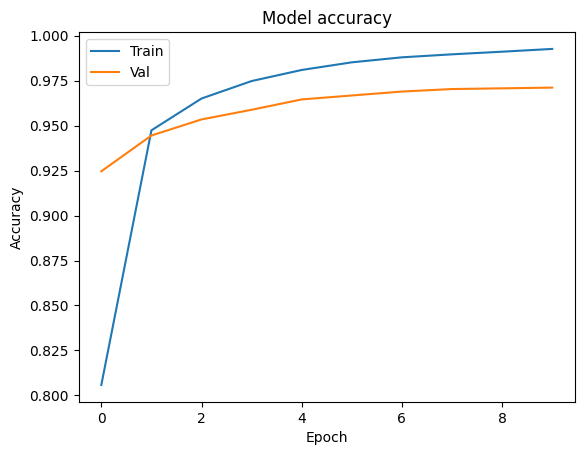

In [30]:
# Plot History 
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

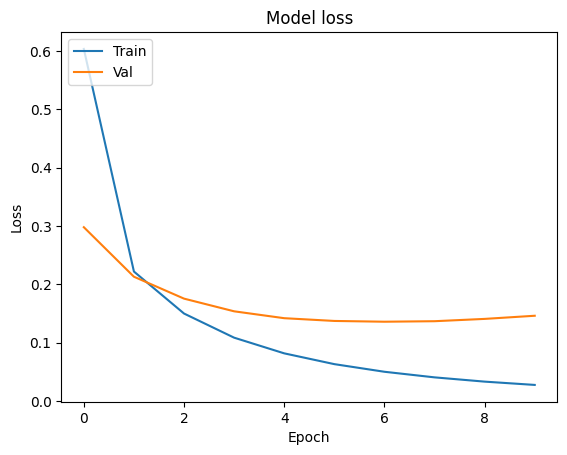

In [31]:
# Plot Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Test

## Tokenize Test Split

In [32]:
X_test = tokenizer.texts_to_sequences(X_test)
X_test = pad_sequences(X_test, maxlen=100, padding='post', truncating='post')

y_test = encoder.transform(y_test)

## Create DataLoader

In [ ]:
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

## Test Model

In [34]:
model.evaluate(test_dataset.batch(32))

158/158 [==============================] - 1s 4ms/step - loss: 0.1771 - accuracy: 0.9654


[0.17710797488689423, 0.9654144048690796]

## Inference with Test Data

In [35]:
# Inference on the model
def predict(text):
    text = tokenizer.texts_to_sequences([text])
    text = pad_sequences(text, maxlen=100, padding='post', truncating='post')
    prediction = model.predict(text)
    return encoder.inverse_transform(prediction)

predict('I am happy')

1/1 [==============================] - 0s 104ms/step


array(['Books'], dtype='<U22')

## Save Model

In [36]:
model.save('model.h5')